# 📦 Demand Forecast Regression — ML Project
## Dataset : Product Demand Forecasting (Kaggle)
## Models Used : Linear Regression | Random Forest | Gradient Boosting
---
**Steps followed in this project:**
1. Import all required libraries (packages)
2. Load the dataset
3. Explore the data (EDA)
4. Clean the data (remove missing & bad values)
5. Feature Engineering (create useful columns)
6. Split the data into Train and Test
7. Train all 3 models
8. Evaluate all models using R², MAE, MSE, RMSE
9. Compare all models
10. Save the best model


## Step 1 : Import All Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2 : Load the Dataset
📌 **Download the dataset from Kaggle:**
> https://www.kaggle.com/datasets/felixzhao/productdemandforecasting
>
> File name: 
> Place the CSV file in the same folder as this notebook.


In [2]:
# Read the CSV file
df = pd.read_csv("Historical Product Demand.csv")

# Show first 5 rows
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


## Step 3 : Explore the Data (EDA)

In [3]:
# Check the shape — how many rows and columns
print("Shape of dataset:", df.shape)

Shape of dataset: (1048575, 5)


In [4]:
# Check column names
print("Columns:", df.columns.tolist())

Columns: ['Product_Code', 'Warehouse', 'Product_Category', 'Date', 'Order_Demand']


In [5]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1048575 non-null  object
 1   Warehouse         1048575 non-null  object
 2   Product_Category  1048575 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1048575 non-null  object
dtypes: object(5)
memory usage: 40.0+ MB


In [6]:
# Basic statistics of the dataset
df.describe()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
count,1048575,1048575,1048575,1037336,1048575
unique,2160,4,33,1729,3828
top,Product_1359,Whse_J,Category_019,2013/9/27,1000
freq,16936,764447,481099,2075,112682


In [7]:
# Check how many missing values are in each column
print("Missing Values in each column:")
print(df.isnull().sum())

Missing Values in each column:
Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64


In [8]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 122423


## Step 4 : Clean the Data

In [9]:
# Remove duplicate rows
df = df.drop_duplicates()

# The "Order_Demand" column has values like "(100)" which means negative
# We need to clean this column and convert it to numbers
df["Order_Demand"] = df["Order_Demand"].astype(str)

# Remove brackets like (100) -> -100 (but we will just remove them and keep positive values)
df["Order_Demand"] = df["Order_Demand"].str.replace("(", "", regex=False)
df["Order_Demand"] = df["Order_Demand"].str.replace(")", "", regex=False)

# Convert to numbers, any non-number will become NaN
df["Order_Demand"] = pd.to_numeric(df["Order_Demand"], errors="coerce")

# Remove rows where Order_Demand is missing or less than or equal to 0
df = df[df["Order_Demand"] > 0]

# Reset the row numbers
df = df.reset_index(drop=True)

print("Data cleaned! Shape now:", df.shape)

Data cleaned! Shape now: (906506, 5)


## Step 5 : Feature Engineering — Create Useful Columns from Date

In [10]:
# Convert the Date column to proper date format
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Drop rows where Date could not be converted
df = df.dropna(subset=["Date"])

# Extract Month, Year, and Day from the Date column
df["Month"] = df["Date"].dt.month        # 1 to 12
df["Year"] = df["Date"].dt.year           # e.g. 2012, 2013
df["DayOfWeek"] = df["Date"].dt.dayofweek  # 0=Monday, 6=Sunday

print("New columns added: Month, Year, DayOfWeek")
df[["Date", "Month", "Year", "DayOfWeek"]].head()

New columns added: Month, Year, DayOfWeek


,Date,Month,Year,DayOfWeek
0,2012-07-27,7,2012,4
1,2012-01-19,1,2012,3
2,2012-02-03,2,2012,4
3,2012-02-09,2,2012,3
4,2012-03-02,3,2012,4


In [11]:
# Label Encode the Product_Category and Warehouse columns
# Because machine learning models only understand numbers, not text
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Warehouse_Encoded"] = le.fit_transform(df["Warehouse"])
df["Category_Encoded"] = le.fit_transform(df["Product_Category"])

print("Encoding done!")
df[["Warehouse", "Warehouse_Encoded", "Product_Category", "Category_Encoded"]].head()

Encoding done!


,Warehouse,Warehouse_Encoded,Product_Category,Category_Encoded
0,Whse_J,2,Category_028,27
1,Whse_J,2,Category_028,27
2,Whse_J,2,Category_028,27
3,Whse_J,2,Category_028,27
4,Whse_J,2,Category_028,27


## Step 5.1 : Visualize the Data

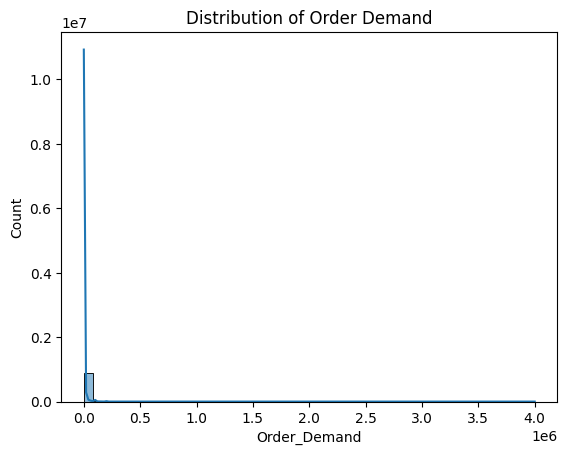

In [28]:
# See how Order Demand is distributed
sns.histplot(df["Order_Demand"], bins=50, kde=True)
plt.title("Distribution of Order Demand")
plt.show()

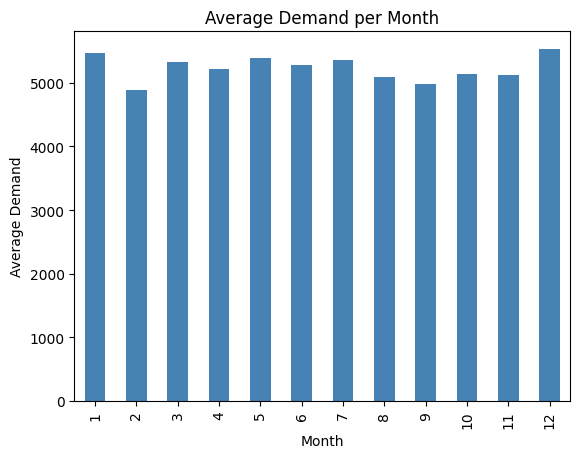

In [13]:
# Average demand per month
monthly_demand = df.groupby("Month")["Order_Demand"].mean()

monthly_demand.plot(kind="bar", color="steelblue")
plt.title("Average Demand per Month")
plt.xlabel("Month")
plt.ylabel("Average Demand")
plt.show()

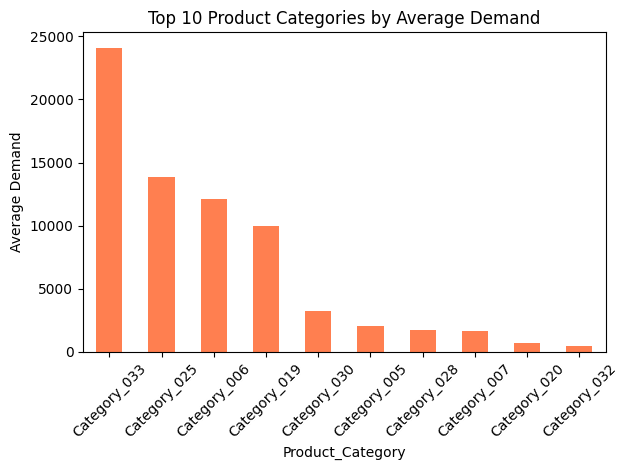

In [14]:
# Average demand per Product Category
cat_demand = df.groupby("Product_Category")["Order_Demand"].mean().sort_values(ascending=False)

cat_demand.head(10).plot(kind="bar", color="coral")
plt.title("Top 10 Product Categories by Average Demand")
plt.ylabel("Average Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 6 : Prepare Features (X) and Target (y), then Split the Data

In [15]:
# Select only the useful number columns for the model
# X = input columns (features)
# y = output column (what we want to predict)

X = df[["Warehouse_Encoded", "Category_Encoded", "Month", "Year", "DayOfWeek"]]
y = df["Order_Demand"]

print("Input Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Input Features (X) shape: (904633, 5)
Target (y) shape: (904633,)


In [16]:
from sklearn.model_selection import train_test_split

# 80% data for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 723706
Testing rows : 180927


## Step 7 : Scale the Data (Standardization)
> Used for Linear Regression (distance-based)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


## Step 8 : Model 1 — Linear Regression

In [18]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_scaled, y_train)

# Predict on test data
lr_pred = lr_model.predict(X_test_scaled)

print("Linear Regression training done!")

Linear Regression training done!


## Step 9 : Model 2 — Random Forest Regressor

In [19]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model (no scaling needed for Random Forest)
rf_model.fit(X_train, y_train)

# Predict on test data
rf_pred = rf_model.predict(X_test)

print("Random Forest training done!")

Random Forest training done!


## Step 10 : Model 3 — Gradient Boosting Regressor

In [20]:
from sklearn.ensemble import GradientBoostingRegressor

# Create the Gradient Boosting model
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Train the model (no scaling needed for Gradient Boosting)
gb_model.fit(X_train, y_train)

# Predict on test data
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting training done!")

Gradient Boosting training done!


## Step 11 : Evaluate All 3 Models
> Metrics used: R² Score, MAE, MSE, RMSE

In [21]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Function to calculate and print all metrics easily
def evaluate_model(model_name, y_actual, y_predicted):
    r2   = r2_score(y_actual, y_predicted)
    mae  = mean_absolute_error(y_actual, y_predicted)
    mse  = mean_squared_error(y_actual, y_predicted)
    rmse = np.sqrt(mse)
    print(f"--- {model_name} ---")
    print(f"  R2 Score : {r2:.4f}")
    print(f"  MAE      : {mae:.2f}")
    print(f"  MSE      : {mse:.2f}")
    print(f"  RMSE     : {rmse:.2f}")
    print()
    return {"Model": model_name, "R2": round(r2,4), "MAE": round(mae,2), "MSE": round(mse,2), "RMSE": round(rmse,2)}

# Evaluate all 3 models
lr_results = evaluate_model("Linear Regression",    y_test, lr_pred)
rf_results = evaluate_model("Random Forest",         y_test, rf_pred)
gb_results = evaluate_model("Gradient Boosting",     y_test, gb_pred)

--- Linear Regression ---
  R2 Score : 0.0065
  MAE      : 7536.76
  MSE      : 889496817.38
  RMSE     : 29824.43

--- Random Forest ---
  R2 Score : 0.0591
  MAE      : 6478.09
  MSE      : 842446969.15
  RMSE     : 29024.94

--- Gradient Boosting ---
  R2 Score : 0.0652
  MAE      : 6579.79
  MSE      : 836936419.12
  RMSE     : 28929.85



## Step 12 : Compare All Models

In [23]:
# Put all results in a table
results_df = pd.DataFrame([lr_results, rf_results, gb_results])
results_df = results_df.set_index("Model")
print(results_df)

# Find the best model based on R2 Score (higher is better)
best_model_name = results_df["R2"].idxmax()
best_r2 = results_df["R2"].max()
print(f"Best Model : {best_model_name} with R2 Score = {best_r2}")

                       R2      MAE           MSE      RMSE
Model                                                     
Linear Regression  0.0065  7536.76  8.894968e+08  29824.43
Random Forest      0.0591  6478.09  8.424470e+08  29024.94
Gradient Boosting  0.0652  6579.79  8.369364e+08  28929.85
Best Model : Gradient Boosting with R2 Score = 0.0652


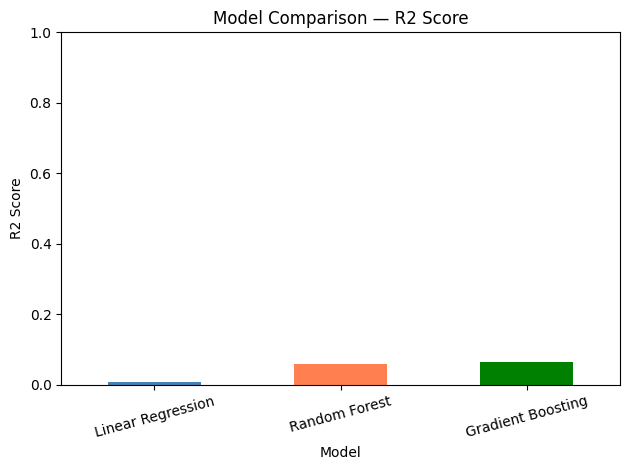

In [24]:
# Bar chart to visually compare R2 Score of all 3 models
results_df["R2"].plot(kind="bar", color=["steelblue", "coral", "green"])
plt.title("Model Comparison — R2 Score")
plt.ylabel("R2 Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Step 13 : Save the Best Model

In [25]:
import joblib

# Save the best model to a file so we can use it later without training again
joblib.dump(rf_model, "demand_forecast_rf_model.pkl")
joblib.dump(scaler,   "demand_forecast_scaler.pkl")

print("Best model (Random Forest) saved as: demand_forecast_rf_model.pkl")
print("Scaler saved as                    : demand_forecast_scaler.pkl")

Best model (Random Forest) saved as: demand_forecast_rf_model.pkl
Scaler saved as                    : demand_forecast_scaler.pkl


## Step 14 : Predict Demand for a New Input

In [26]:
# Example: Predict demand for a product
# Warehouse=0, Category=3, Month=6, Year=2016, DayOfWeek=2

new_input = np.array([[0, 3, 6, 2016, 2]])

predicted_demand = rf_model.predict(new_input)

print(f"Predicted Order Demand: {predicted_demand[0]:.0f} units")

Predicted Order Demand: 62 units


## 📝 Key Notes (As taught by Sir)

| Concept | Description |
|---|---|
| **StandardScaler** | Used for Linear Regression — scales data to mean=0, std=1 |
| **LabelEncoder** | Converts text categories to numbers |
| **train_test_split** | 80% train, 20% test, random_state=42 |
| **R² Score** | How well the model fits (closer to 1 is better) |
| **MAE** | Average prediction error |
| **RMSE** | Penalizes large errors more |
| **joblib.dump** | Saves the trained model to a file |
| **Random Forest** | Best model for this dataset — handles non-linear data well |
| **Gradient Boosting** | Learns from previous mistakes — usually very accurate |
| **Linear Regression** | Simple baseline model — works best when data is linear |
